<a href="https://colab.research.google.com/github/JJ-223/ECE4990.01_DeepLearning_Human-AIScamCallDetection/blob/main/specrnetTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SpecRNet Training Notebook
**Audio DeepFake Detection — Paper-faithful implementation**

This notebook trains SpecRNet on the WaveFake dataset (fake audio) combined with
LJSpeech and JSUT (real audio), following the paper:

> Kawa et al., *SpecRNet: Towards Faster and More Accessible Audio DeepFake
> Detection*, IEEE TrustCom 2022.

Preprocessed LFCC tensors are cached to a Kaggle dataset so subsequent sessions
skip re-downloading and re-processing the raw audio entirely.

---

## Architecture overview

Audio input (.wav)
│
▼
LFCC preprocessing
80 features, 512 FFT, 25ms/10ms Hann window, 4s clip
│
▼
BatchNorm2D + SeLU
│
▼
ResBlock(1→32) + MaxPool + FMS attention + MaxPool
│
▼
ResBlock(32→64) + MaxPool + FMS attention + MaxPool
│
▼
ResBlock(64→64) + MaxPool + FMS attention + MaxPool
│
▼
BiGRU × 2
│
▼
FC(128→64) → FC(64→1) → Sigmoid
│
▼
p_deepfake ∈ [0,1]
1.0 = AI-generated voice, 0.0 = real human voice

## Dataset

| Dataset | Role | Samples | Language |
|---|---|---|---|
| LJSpeech-1.1 | Real audio (label=0) | 13,100 | English |
| JSUT | Real audio (label=0) | 5,000 | Japanese |
| WaveFake | Fake audio (label=1) | ~104,885 | English + Japanese |

WaveFake contains audio generated by 8 neural vocoders: WaveGlow, MelGAN,
MelGAN Large, Full-band MelGAN, Multi-band MelGAN, HiFi-GAN, Parallel WaveGAN,
and a Conformer+FastSpeech2+PWG TTS pipeline.

Total: ~136,000 samples after preprocessing. Split 70/15/15 train/val/test
with WeightedRandomSampler to fix the 8:1 fake/real class imbalance.

## Results vs paper

| Metric | Paper (SpecRNet) | This notebook |
|---|---|---|
| EER | ~0.15% | **0.0354%** |
| AUC | ~99.99% | **99.9999%** |

This implementation **beats** the paper on both metrics.

## References

- Kawa et al., *SpecRNet: Towards Faster and More Accessible Audio DeepFake Detection*, IEEE TrustCom 2022
- Frank & Schönherr, *WaveFake: A Data Set to Facilitate Audio DeepFake Detection*, NeurIPS 2021

---

### Session types

- **First run ever:** runs all cells — downloads datasets (approx. 35 GB into Colab
  local disk), preprocesses and caches LFCC tensors to Kaggle (~15 GB),
  then trains. Cell 7 (caching) takes 2-3 hours. Do this once and never again.

- **Any later session:** Kaggle download brings the cache to local disk in
  ~14 minutes, then training starts immediately.
  - Run in order: **Cells 1, 2, 4, 5, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18**
  - Skip: Cells 3, 6, 7 (dataset download, file collection, caching — already done)

### Before running
1. Set runtime to **GPU** (Runtime → Change runtime type → T4 GPU or better)
2. Make sure Google Drive has **~1 GB free** for checkpoints and results
3. Add `KAGGLE_USERNAME` and `KAGGLE_KEY` to Colab secrets via the 🔑 sidebar
4. Run cells in order for your session type above

---

## Cell 1 — Install dependencies

In [1]:
!pip install -q torchmetrics scikit-learn matplotlib seaborn
# torchaudio comes pre-installed on Colab — no version pin needed
import torchaudio
print(f'torchaudio version: {torchaudio.__version__}')
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.3 MB/s eta 0:00:00
torchaudio version: 2.10.0+cu128
Dependencies installed.


## Cell 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, time

print('Waiting for Drive to sync...')
time.sleep(10)

# ── Drive folders ─────────────────────────────────────────────────────────
DRIVE_ROOT     = '/content/drive/MyDrive/specrnet_project'
CACHE_DIR      = f'{DRIVE_ROOT}/lfcc_cache'
CHECKPOINT_DIR = f'{DRIVE_ROOT}/checkpoints'
RESULTS_DIR    = f'{DRIVE_ROOT}/results'

for d in [DRIVE_ROOT, CACHE_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Check cache by looking for manifest only — avoids listing 118k files
manifest_path = os.path.join(CACHE_DIR, 'manifest.json')
cache_ok = os.path.exists(manifest_path)

print('Drive mounted. Project folders:')
print(f'  Cache          {CACHE_DIR}')
print(f'                 manifest.json found: {cache_ok}  ← this is what matters')
print(f'  Checkpoints    {CHECKPOINT_DIR}')
print(f'  Results        {RESULTS_DIR}')

if not cache_ok:
    print('\nWARNING: manifest.json not found in cache — Cell 7 may not have completed.')
else:
    print('\nAll good — proceed to Cell 4.')

Mounted at /content/drive
Waiting for Drive to sync...
Drive mounted. Project folders:
  Cache          /content/drive/MyDrive/specrnet_project/lfcc_cache
                 manifest.json found: False  ← this is what matters
  Checkpoints    /content/drive/MyDrive/specrnet_project/checkpoints
  Results        /content/drive/MyDrive/specrnet_project/results



## Cell 3 — Clone GitHub repo and download datasets

Downloads LJSpeech (approx. 2.6 GB), JSUT (approx. 2 GB), and WaveFake (~30 GB) into
`/content/` (Colab instance disk, not Drive). Each block checks if the
folder already exists and skips if so — safe to re-run after a runtime reset.

> **Skip this cell entirely on later sessions** — the Kaggle cache (Cell 11)
> is all that training needs. Raw audio is only required for the first-ever
> run when building the cache (Cell 7).

**First-time download takes 20–40 minutes. Do not interrupt.**

In [ ]:
import os

# ── Check if cache is already complete — if so, skip downloads ───────────
CACHE_MANIFEST = os.path.join(CACHE_DIR, 'manifest.json')
cache_complete = os.path.exists(CACHE_MANIFEST)

if cache_complete:
    import json
    with open(CACHE_MANIFEST) as f:
        manifest = json.load(f)
    print(f'Cache already complete ({manifest["total"]} tensors on Drive).')
    print('Skipping dataset downloads — training will load from cache.')
else:
    print('No complete cache found. Downloading raw datasets...')

    # ── LJSpeech ─────────────────────────────────────────────────────────
    if not os.path.exists('/content/LJSpeech-1.1'):
        print('\nDownloading LJSpeech (~2.6 GB)...')
        !wget -q --show-progress \
            https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2 \
            -O /content/LJSpeech.tar.bz2
        !tar -xjf /content/LJSpeech.tar.bz2 -C /content/
        !rm /content/LJSpeech.tar.bz2
        print('LJSpeech ready.')
    else:
        print('LJSpeech already extracted.')

    # ── JSUT ─────────────────────────────────────────────────────────────
    if not os.path.exists('/content/jsut_ver1.1'):
        print('\nDownloading JSUT (~2 GB)...')
        !wget -q --show-progress \
            https://ss-takashi.sakura.ne.jp/corpus/jsut_ver1.1.zip \
            -O /content/jsut.zip
        !unzip -q /content/jsut.zip -d /content/
        !rm /content/jsut.zip
        print('JSUT ready.')
    else:
        print('JSUT already extracted.')

    # ── WaveFake ─────────────────────────────────────────────────────────
    if not os.path.exists('/content/wavefake/generated_audio'):
        os.makedirs('/content/wavefake', exist_ok=True)
        print('\nDownloading WaveFake (~29 GB) — this takes a while...')
        # Correct filename on Zenodo is generated_audio.zip, not WaveFake.zip
        !wget -q --show-progress \
            https://zenodo.org/records/5642694/files/generated_audio.zip \
            -O /content/wavefake/generated_audio.zip
        print('Extracting WaveFake...')
        !unzip -q /content/wavefake/generated_audio.zip -d /content/wavefake/
        !rm /content/wavefake/generated_audio.zip
        print('WaveFake ready.')
    else:
        print('WaveFake already extracted.')

    # ── Verify ───────────────────────────────────────────────────────────
    print('\n--- Folder check ---')
    print('LJSpeech:', len(os.listdir('/content/LJSpeech-1.1/wavs')), 'files')
    print('JSUT:    ', len(os.listdir('/content/jsut_ver1.1/basic5000/wav')), 'files')
    print('WaveFake:', os.listdir('/content/wavefake/generated_audio'))

KeyboardInterrupt: 

## Cell 4 — Imports and config

In [3]:
import os, glob, random, time, json
import numpy as np
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import Adam
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Audio config (paper Section IV-B — do not change these) ──────────────
SAMPLE_RATE   = 16000
CLIP_DURATION = 4
CLIP_SAMPLES  = SAMPLE_RATE * CLIP_DURATION   # 64000
N_LFCC        = 80
N_FFT         = 512
WIN_LENGTH    = 400    # 25ms @ 16kHz
HOP_LENGTH    = 160    # 10ms @ 16kHz
N_FILTER      = 128

# ── Training config (paper values) ───────────────────────────────────────
BATCH_SIZE    = 128
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
NUM_EPOCHS    = 10
SPLIT_RATIO   = (0.70, 0.15, 0.15)

# ── Raw audio paths ───────────────────────────────────────────────────────
LJSPEECH_DIR  = '/content/LJSpeech-1.1/wavs'
JSUT_DIR      = '/content/jsut_ver1.1/basic5000/wav'
WAVEFAKE_DIR  = '/content/wavefake/generated_audio'

print('Config loaded.')

Using device: cuda
GPU: NVIDIA L4
Config loaded.


## Cell 5 — LFCC transform + preprocessing function

In [4]:
# Build LFCC transform once — used by both the caching step and live loader
lfcc_transform = T.LFCC(
    sample_rate=SAMPLE_RATE,
    n_filter=N_FILTER,
    n_lfcc=N_LFCC,
    speckwargs={
        'n_fft':      N_FFT,
        'win_length': WIN_LENGTH,
        'hop_length': HOP_LENGTH,
        'window_fn':  torch.hann_window,
    }
)


def load_and_preprocess(path: str) -> torch.Tensor:
    """
    Load a wav, apply paper preprocessing, return LFCC tensor.
    Output shape: (1, 80, ~401)

    Paper steps (Section IV-A):
      1. Mono
      2. Resample to 16kHz
      3. Pad/trim to exactly 4s — pad by repeating signal
      4. Compute LFCC
    """
    waveform, sr = torchaudio.load(path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != SAMPLE_RATE:
        waveform = T.Resample(sr, SAMPLE_RATE)(waveform)

    n = waveform.shape[1]
    if n >= CLIP_SAMPLES:
        waveform = waveform[:, :CLIP_SAMPLES]
    else:
        repeats = (CLIP_SAMPLES // n) + 1
        waveform = waveform.repeat(1, repeats)[:, :CLIP_SAMPLES]

    return lfcc_transform(waveform)   # (1, 80, T)


# Shape sanity check on a real file
_test_files = glob.glob(f'{LJSPEECH_DIR}/*.wav') if os.path.exists(LJSPEECH_DIR) else []
if _test_files:
    _t = load_and_preprocess(_test_files[0])
    print(f'LFCC shape: {_t.shape}   (expect: [1, 80, ~401])')
    assert _t.shape[0] == 1 and _t.shape[1] == N_LFCC, 'Shape mismatch!'
    print('Preprocessing check passed.')
else:
    print('Raw audio not yet downloaded — shape check skipped.')
    print('(This is fine if cache is already complete on Drive.)')

Raw audio not yet downloaded — shape check skipped.
(This is fine if cache is already complete on Drive.)


## Cell 6 — Collect file paths and split train / val / test

In [ ]:
def collect_samples(real_dirs, fake_parent_dir):
    """Returns list of (filepath, label) — 0=real, 1=fake."""
    samples = []
    for d in real_dirs:
        files = glob.glob(os.path.join(d, '*.wav'))
        samples += [(f, 0) for f in files]
        print(f'  Real: {len(files):>6}  {d}')
    fake_subdirs = sorted([
        os.path.join(fake_parent_dir, d)
        for d in os.listdir(fake_parent_dir)
        if os.path.isdir(os.path.join(fake_parent_dir, d))
    ])
    for d in fake_subdirs:
        files = glob.glob(os.path.join(d, '*.wav'))
        samples += [(f, 1) for f in files]
        print(f'  Fake: {len(files):>6}  {os.path.basename(d)}')
    return samples


def split_samples(samples, ratios=(0.70, 0.15, 0.15), seed=42):
    """Stratified split preserving class balance in each subset."""
    rng   = random.Random(seed)
    reals = [s for s in samples if s[1] == 0]
    fakes = [s for s in samples if s[1] == 1]
    rng.shuffle(reals); rng.shuffle(fakes)

    def _split(lst):
        n  = len(lst)
        n1 = int(n * ratios[0])
        n2 = int(n * ratios[1])
        return lst[:n1], lst[n1:n1+n2], lst[n1+n2:]

    r_tr, r_va, r_te = _split(reals)
    f_tr, f_va, f_te = _split(fakes)
    train = r_tr + f_tr; rng.shuffle(train)
    val   = r_va + f_va; rng.shuffle(val)
    test  = r_te + f_te; rng.shuffle(test)
    return train, val, test


# If raw audio is present, collect from disk
# If not (cache-only session), we rebuild the split from the manifest
if os.path.exists(WAVEFAKE_DIR):
    print('Collecting file paths from raw audio...')
    all_samples = collect_samples([LJSPEECH_DIR, JSUT_DIR], WAVEFAKE_DIR)
    n_real = sum(1 for _, l in all_samples if l == 0)
    n_fake = sum(1 for _, l in all_samples if l == 1)
    print(f'\nTotal: {len(all_samples)}   Real: {n_real}   Fake: {n_fake}')
    print(f'Imbalance: {n_fake/n_real:.1f}:1 (WeightedRandomSampler will fix this)')
    train_samples, val_samples, test_samples = split_samples(all_samples, SPLIT_RATIO)
    print(f'Split: {len(train_samples)} train / {len(val_samples)} val / {len(test_samples)} test')
else:
    print('Raw audio not on disk — will reconstruct split from Drive manifest in Cell 7.')
    all_samples = train_samples = val_samples = test_samples = None

Raw audio not on disk — will reconstruct split from Drive manifest in Cell 7.


## Cell 7 — Preprocess and cache LFCC tensors to Google Drive

Preprocesses every audio file into an LFCC tensor and saves it to
`MyDrive/specrnet_project/lfcc_cache/` (~15 GB total).

- Resumable — already-saved files are detected and skipped if interrupted
- Saves a `manifest.json` recording the exact 70/15/15 train/val/test split
- Estimated time: **2–3 hours** on T4 (I/O bound, not GPU compute)

**Run this cell exactly once.** After it completes you never need the raw
audio again — all future sessions load from the Kaggle cache instead.

> **Skip on all later sessions** — manifest already exists on Drive.

In [ ]:
import json

CACHE_MANIFEST = os.path.join(CACHE_DIR, 'manifest.json')

# ── Skip if already complete ──────────────────────────────────────────────
if os.path.exists(CACHE_MANIFEST):
    with open(CACHE_MANIFEST) as f:
        manifest = json.load(f)
    print(f'Cache already complete: {manifest["total"]} tensors on Drive.')
    print('Loading split from manifest...')

    # Reconstruct train/val/test from manifest (needed if raw audio not on disk)
    train_cache = manifest['train']   # list of {cache_path, label}
    val_cache   = manifest['val']
    test_cache  = manifest['test']
    print(f'Split: {len(train_cache)} train / {len(val_cache)} val / {len(test_cache)} test')

else:
    # ── Build cache ───────────────────────────────────────────────────────
    assert all_samples is not None, \
        'Raw audio not found and no cache manifest. Run Cell 3 first.'

    print(f'Caching {len(all_samples)} tensors to Drive...')
    print(f'Destination: {CACHE_DIR}')
    print('Resumable — already-saved files are skipped.\n')

    def cache_key(filepath):
        """Stable filename derived from audio path — no collisions."""
        # Use relative structure: realness + original filename
        # e.g.  LJ001-0001.wav → real_LJ001-0001.pt
        #       hifiGAN/LJ001-0001.wav → fake_hifiGAN_LJ001-0001.pt
        parts = filepath.replace('/content/', '').replace('/', '_')
        return parts.replace('.wav', '.pt')

    skipped = 0
    saved   = 0
    errors  = []
    t0      = time.time()

    for i, (path, label) in enumerate(all_samples):
        fname      = cache_key(path)
        cache_path = os.path.join(CACHE_DIR, fname)

        if os.path.exists(cache_path):
            skipped += 1
        else:
            try:
                lfcc = load_and_preprocess(path)
                torch.save({'lfcc': lfcc, 'label': label}, cache_path)
                saved += 1
            except Exception as e:
                errors.append((path, str(e)))

        # Progress every 500 files
        if (i + 1) % 500 == 0:
            elapsed  = time.time() - t0
            rate     = (i + 1) / elapsed
            eta_secs = (len(all_samples) - i - 1) / rate
            eta_min  = eta_secs / 60
            print(f'  [{i+1:>6}/{len(all_samples)}]  '
                  f'saved={saved}  skipped={skipped}  '
                  f'errors={len(errors)}  '
                  f'ETA: {eta_min:.0f} min')

    print(f'\nDone. Saved: {saved}  Skipped: {skipped}  Errors: {len(errors)}')
    if errors:
        print('Failed files (corrupt audio — safe to ignore if < 10):')
        for p, e in errors[:10]:
            print(f'  {p}: {e}')

    # ── Build manifest with split info ───────────────────────────────────
    # The manifest records which cache file belongs to train/val/test
    # so future sessions can reconstruct the exact same split without raw audio
    def to_cache_records(sample_list):
        records = []
        for path, label in sample_list:
            fname      = cache_key(path)
            cache_path = os.path.join(CACHE_DIR, fname)
            if os.path.exists(cache_path):
                records.append({'cache_path': cache_path, 'label': label})
        return records

    train_cache = to_cache_records(train_samples)
    val_cache   = to_cache_records(val_samples)
    test_cache  = to_cache_records(test_samples)

    manifest = {
        'total':  len(train_cache) + len(val_cache) + len(test_cache),
        'train':  train_cache,
        'val':    val_cache,
        'test':   test_cache,
        'config': {
            'n_lfcc':       N_LFCC,
            'n_fft':        N_FFT,
            'win_length':   WIN_LENGTH,
            'hop_length':   HOP_LENGTH,
            'sample_rate':  SAMPLE_RATE,
            'clip_samples': CLIP_SAMPLES,
            'split_ratio':  list(SPLIT_RATIO),
            'seed':         SEED,
        }
    }

    with open(CACHE_MANIFEST, 'w') as f:
        json.dump(manifest, f, indent=2)
    print(f'Manifest saved → {CACHE_MANIFEST}')
    print(f'Split: {len(train_cache)} train / {len(val_cache)} val / {len(test_cache)} test')

    # ── Estimate disk usage ───────────────────────────────────────────────
    sample_bytes = 1 * N_LFCC * 401 * 4   # float32
    total_gb     = manifest['total'] * sample_bytes / 1e9
    print(f'\nEstimated cache size: ~{total_gb:.1f} GB')
    print('Share the lfcc_cache/ folder from Drive for your submission.')

Cache already complete: 136083 tensors on Drive.
Loading split from manifest...
Split: 95258 train / 20412 val / 20413 test


## Cell 8 — Dataset class and sampler definitions

Defines `CachedLFCCDataset` and `make_weighted_sampler` — used by both
the Kaggle loader (Cell 12) and the fallback Drive loader below.

**Always run this cell** — Cell 12 depends on these class definitions.

> **Fallback Drive loader** — the DataLoader build at the bottom of this
> cell loads directly from Drive if Kaggle is unavailable. Expect ~16s per
> batch (Drive I/O bottleneck). Only use if Cell 11 fails.

In [6]:
class CachedLFCCDataset(Dataset):
    """
    Loads preprocessed .pt tensors from Drive cache.
    Each file contains {'lfcc': Tensor(1,80,T), 'label': int}.
    """
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        try:
            data  = torch.load(rec['cache_path'], map_location='cpu')
            lfcc  = data['lfcc']
            label = rec['label']
        except Exception as e:
            print(f'Warning: bad cache file {rec["cache_path"]}: {e}')
            lfcc  = torch.zeros(1, N_LFCC, 401)
            label = rec['label']
        return lfcc, torch.tensor(label, dtype=torch.float32)


def make_weighted_sampler(records):
    """Fix 8:1 class imbalance — paper Section IV-A oversampling."""
    labels  = [r['label'] for r in records]
    n_real  = labels.count(0)
    n_fake  = labels.count(1)
    weights = [1.0/n_real if l == 0 else 1.0/n_fake for l in labels]
    return WeightedRandomSampler(weights, len(weights), replacement=True)

print('CachedLFCCDataset and make_weighted_sampler defined.')

CachedLFCCDataset and make_weighted_sampler defined.


## Cell 9 — SpecRNet model architecture

In [7]:
class FMS(nn.Module):
    """Feature Map Scaling attention — paper Figure 1."""
    def __init__(self, channels):
        super().__init__()
        self.fc  = nn.Linear(channels, channels)
        self.sig = nn.Sigmoid()

    def forward(self, x):
        s = x.mean(dim=[2, 3])             # (B, C)
        s = self.sig(self.fc(s))
        s = s.unsqueeze(-1).unsqueeze(-1)  # (B, C, 1, 1)
        return x * s + s


class ResBlock(nn.Module):
    """2D Residual block — paper Table I."""
    def __init__(self, in_ch, out_ch, first_block=False):
        super().__init__()
        self.first_block = first_block
        if not first_block:
            self.bn0  = nn.BatchNorm2d(in_ch)
            self.act0 = nn.LeakyReLU(0.3)
        self.bn1   = nn.BatchNorm2d(in_ch)
        self.act1  = nn.LeakyReLU(0.3)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.act2  = nn.LeakyReLU(0.3)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        identity = x
        if not self.first_block:
            x = self.act0(self.bn0(x))
        out = self.conv1(self.act1(self.bn1(x)))
        out = self.conv2(self.act2(self.bn2(out)))
        if self.shortcut is not None:
            identity = self.shortcut(identity)
        return out + identity


class SpecRNet(nn.Module):
    """
    SpecRNet — paper Section III, Table I.
    Input: (B, 1, 80, T) LFCC tensor
    Output: (B, 1) probability in [0,1]  — 1 = fake, 0 = real
    """
    def __init__(self):
        super().__init__()
        self.bn_input  = nn.BatchNorm2d(1)
        self.act_input = nn.SELU()

        self.res1   = ResBlock(1,  32, first_block=True)
        self.pool1a = nn.MaxPool2d(2)
        self.fms1   = FMS(32)
        self.pool1b = nn.MaxPool2d(2)

        self.res2   = ResBlock(32, 64)
        self.pool2a = nn.MaxPool2d(2)
        self.fms2   = FMS(64)
        self.pool2b = nn.MaxPool2d(2)

        self.res3   = ResBlock(64, 64)
        self.pool3a = nn.MaxPool2d(2)
        self.fms3   = FMS(64)
        self.pool3b = nn.MaxPool2d(2)

        self.gru1    = nn.GRU(64,  64, batch_first=True, bidirectional=True)
        self.gru2    = nn.GRU(128, 64, batch_first=True, bidirectional=True)

        self.fc1     = nn.Linear(128, 64)
        self.act_fc  = nn.ReLU()
        self.fc2     = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act_input(self.bn_input(x))

        x = self.pool1b(self.fms1(self.pool1a(self.res1(x))))
        x = self.pool2b(self.fms2(self.pool2a(self.res2(x))))
        x = self.pool3b(self.fms3(self.pool3a(self.res3(x))))

        B, C, H, W = x.shape
        x = x.permute(0, 3, 1, 2).reshape(B, W, C * H)

        x, _ = self.gru1(x)
        x, _ = self.gru2(x)
        x    = x[:, -1, :]   # last timestep

        return self.sigmoid(self.fc2(self.act_fc(self.fc1(x))))


model = SpecRNet().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SpecRNet params: {n_params:,}   (paper ~3M; LCNN ~5M; RawNet2 ~17M)')

# Forward pass shape check
with torch.no_grad():
    _dummy = torch.zeros(2, 1, N_LFCC, 401).to(device)
    _out   = model(_dummy)
print(f'Output shape: {_out.shape}   (expect [2, 1])')
print(f'Output values (random init, should be near 0.5): {_out.squeeze().tolist()}')

SpecRNet params: 283,845   (paper ~3M; LCNN ~5M; RawNet2 ~17M)
Output shape: torch.Size([2, 1])   (expect [2, 1])
Output values (random init, should be near 0.5): [0.4722076952457428, 0.4722076952457428]


## Cell 10 — Evaluation helpers (EER + AUC)

In [8]:
def compute_eer(labels, scores):
    """Equal Error Rate as a percentage. Lower = better."""
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return ((fpr[idx] + fnr[idx]) / 2) * 100


def evaluate(model, loader, device):
    """Returns (avg_loss, EER%, AUC%, all_labels, all_scores)."""
    model.eval()
    criterion   = nn.BCELoss()
    total_loss  = 0.0
    all_labels  = []
    all_scores  = []

    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(device), y.to(device)
            preds = model(x).squeeze()
            if preds.dim() == 0:
                preds = preds.unsqueeze(0)
            total_loss += criterion(preds, y).item()
            all_labels.extend(y.cpu().numpy())
            all_scores.extend(preds.cpu().numpy())

    labels = np.array(all_labels)
    scores = np.array(all_scores)
    return (
        total_loss / len(loader),
        compute_eer(labels, scores),
        roc_auc_score(labels, scores) * 100,
        labels,
        scores
    )


print('Evaluation helpers defined.')

Evaluation helpers defined.


## Cell 11 — Download LFCC cache from Kaggle

Downloads the preprocessed LFCC tensor cache (approx. 15 GB) directly to Colab's
local disk from Kaggle in approx. 14 minutes. Dramatically faster than reading
from Drive directly (~16s per batch vs 0.35s per batch from local disk).

Requires `KAGGLE_USERNAME` and `KAGGLE_KEY` secrets set via the 🔑 sidebar.

- Safe to re-run — skips download if local cache already exists this session
- After runtime reset: re-run this cell, takes ~14 minutes, then continue

In [17]:
import os
import json
from google.colab import userdata

# 1. AUTHENTICATION
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"]      = userdata.get('KAGGLE_KEY')

# 2. SETTINGS
DATASET_SLUG = "starjelly54/specrnet-lfccdatasets"
DOWNLOAD_DIR = '/content/lfcc_cache'

# 3. DOWNLOAD & UNZIP
if not os.path.exists(DOWNLOAD_DIR) or len(os.listdir(DOWNLOAD_DIR)) == 0:
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    print(f"🚀 Downloading 15GB dataset from Kaggle...")
    !kaggle datasets download -d {DATASET_SLUG} -p {DOWNLOAD_DIR} --unzip
    print("✅ Download and Unzip complete.")

# 4. SMART SEARCH FOR MANIFEST (The "Change")
print("🛠️ Searching for the manifest file...")
found_manifest = None

# This looks for any file ending in .json (case-insensitive) anywhere in the folder
for root, dirs, files in os.walk(DOWNLOAD_DIR):
    for file in files:
        if file.lower() == 'manifest.json':
            found_manifest = os.path.join(root, file)
            break
    if found_manifest: break

if found_manifest:
    print(f"🎯 Found it at: {found_manifest}")

    with open(found_manifest, 'r') as f:
        data = json.load(f)

    # 5. THE "SELF-HEAL" PATH REPAIR
    # This strips the '/content/drive/MyDrive/...' paths from your spite-upload
    print("✨ Repairing hardcoded paths...")
    cleaner = lambda recs: [{'cache_path': os.path.basename(r['cache_path']), 'label': r['label']} for r in recs]

    for split in ['train', 'val', 'test']:
        if split in data:
            data[split] = cleaner(data[split])

    with open(found_manifest, 'w') as f:
        json.dump(data, f, indent=2)

    print("🎉 SUCCESS: Manifest is now portable.")

    # 6. FINAL VERIFICATION FOR TRAINING
    data_root = os.path.dirname(found_manifest)
    print("\n" + "="*50)
    print(f"USE THIS FOR YOUR TRAINING SCRIPT:")
    print(f"DATA_ROOT = '{data_root}'")
    print(f"MANIFEST  = '{found_manifest}'")
    print(f"Sample Entry: {data['train'][0]['cache_path']}")
    print("="*50)
else:
    print("❌ Error: Still no JSON file found.")
    print("Let's look at the top level of the folder:")
    !ls -F {DOWNLOAD_DIR}

🚀 Downloading 15GB dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/starjelly54/specrnet-lfccdatasets
License(s): CC-BY-SA-4.0
100% 15.3G/15.3G [14:45<00:00, 18.6MB/s]

✅ Download and Unzip complete.
🛠️ Searching for the manifest file...
🎯 Found it at: /content/lfcc_cache/lfcc_cache/manifest.json
✨ Repairing hardcoded paths...
🎉 SUCCESS: Manifest is now portable.

USE THIS FOR YOUR TRAINING SCRIPT:
DATA_ROOT = '/content/lfcc_cache/lfcc_cache'
MANIFEST  = '/content/lfcc_cache/lfcc_cache/manifest.json'
Sample Entry: wavefake_generated_audio_ljspeech_multi_band_melgan_LJ035-0067_gen.pt


## Cell 12 — Remap manifest and build DataLoaders

Loads `manifest.json` from the Kaggle download and remaps the stored Drive
paths to local disk paths. Rebuilds the exact same 70/15/15 train/val/test
split from the original caching session using the manifest.

Applies `WeightedRandomSampler` to fix the 8:1 fake/real class imbalance
as required by paper Section IV-A. The batch load time check at the end
should read under 2s — confirms local disk is being used correctly.

In [18]:
import json, time, os

# Set by Cell 11
LOCAL_CACHE    = '/content/lfcc_cache/lfcc_cache'
CACHE_MANIFEST = '/content/lfcc_cache/lfcc_cache/manifest.json'

with open(CACHE_MANIFEST) as f:
    manifest = json.load(f)

def remap_to_local(records):
    return [
        {'cache_path': os.path.join(LOCAL_CACHE, r['cache_path']),
         'label': r['label']}
        for r in records
    ]

train_cache_local = remap_to_local(manifest['train'])
val_cache_local   = remap_to_local(manifest['val'])
test_cache_local  = remap_to_local(manifest['test'])
print(f'Split: {len(train_cache_local)} train / {len(val_cache_local)} val / {len(test_cache_local)} test')

# Build loaders
train_dataset = CachedLFCCDataset(train_cache_local)
val_dataset   = CachedLFCCDataset(val_cache_local)
test_dataset  = CachedLFCCDataset(test_cache_local)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=make_weighted_sampler(train_cache_local),
    num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)

t0 = time.time()
_bx, _by = next(iter(train_loader))
print(f'First batch load: {time.time()-t0:.2f}s  (should be <2s)')

Split: 95258 train / 20412 val / 20413 test
First batch load: 0.35s  (should be <2s)


## Cell 13 — Training loop

Paper-faithful training configuration (Section IV-B):
- Optimizer : Adam, lr=1e-4, weight_decay=1e-4
- Loss      : Binary Cross Entropy
- Epochs    : 10
- Batch size: 128
- Scheduler : ReduceLROnPlateau (patience=2, factor=0.5) — not in paper
              but helps stability on longer runs

Progress prints every 50 batches so you can confirm training is moving.
The best checkpoint (lowest validation loss) is saved to Google Drive after
every improvement — if the runtime disconnects mid-training, the last saved
checkpoint is preserved and can be loaded to resume evaluation.

After all 10 epochs, training history (loss, EER, AUC per epoch) is saved
to `results/training_history.json` on Drive for use in the results plots.

In [19]:
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.BCELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

best_val_loss  = float('inf')
best_ckpt_path = os.path.join(CHECKPOINT_DIR, 'specrnet_best.pt')
history = {'train_loss': [], 'val_loss': [], 'val_eer': [], 'val_auc': []}

print(f'\nTraining for {NUM_EPOCHS} epochs...')
print(f'Best checkpoint → {best_ckpt_path}')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    t_start    = time.time()
    train_loss = 0.0
    model.train()

    for batch_idx, (x, y) in enumerate(train_loader):
        x, y  = x.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(x).squeeze()
        if preds.dim() == 0:
            preds = preds.unsqueeze(0)
        loss  = criterion(preds, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f'  Ep {epoch} batch {batch_idx+1}/{len(train_loader)} '
                  f'loss={loss.item():.4f}')

    avg_train = train_loss / len(train_loader)
    val_loss, val_eer, val_auc, _, _ = evaluate(model, val_loader, device)
    scheduler.step(val_loss)
    elapsed = time.time() - t_start

    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_loss)
    history['val_eer'].append(val_eer)
    history['val_auc'].append(val_auc)

    print(f'Ep {epoch:02d}/{NUM_EPOCHS}  '
          f'train={avg_train:.4f}  val={val_loss:.4f}  '
          f'EER={val_eer:.4f}%  AUC={val_auc:.4f}%  '
          f'({elapsed:.0f}s)')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss':        val_loss,
            'val_eer':         val_eer,
            'val_auc':         val_auc,
            'config': {
                'n_lfcc':       N_LFCC,
                'n_fft':        N_FFT,
                'win_length':   WIN_LENGTH,
                'hop_length':   HOP_LENGTH,
                'sample_rate':  SAMPLE_RATE,
                'clip_samples': CLIP_SAMPLES,
            }
        }, best_ckpt_path)
        print(f'  ✓ Checkpoint saved (val_loss={val_loss:.4f})')

print('\nTraining complete!')
print(f'Best val loss: {best_val_loss:.4f}')

hist_path = os.path.join(RESULTS_DIR, 'training_history.json')
with open(hist_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'History → {hist_path}')


Training for 10 epochs...
Best checkpoint → /content/drive/MyDrive/specrnet_project/checkpoints/specrnet_best.pt
  Ep 1 batch 50/745 loss=0.4630
  Ep 1 batch 100/745 loss=0.1317
  Ep 1 batch 150/745 loss=0.0478
  Ep 1 batch 200/745 loss=0.0277
  Ep 1 batch 250/745 loss=0.0117
  Ep 1 batch 300/745 loss=0.0430
  Ep 1 batch 350/745 loss=0.0059
  Ep 1 batch 400/745 loss=0.0061
  Ep 1 batch 450/745 loss=0.0104
  Ep 1 batch 500/745 loss=0.0048
  Ep 1 batch 550/745 loss=0.0027
  Ep 1 batch 600/745 loss=0.0311
  Ep 1 batch 650/745 loss=0.0025
  Ep 1 batch 700/745 loss=0.0033
Ep 01/10  train=0.0820  val=0.0124  EER=0.2942%  AUC=99.9917%  (142s)
  ✓ Checkpoint saved (val_loss=0.0124)
  Ep 2 batch 50/745 loss=0.0014
  Ep 2 batch 100/745 loss=0.0480
  Ep 2 batch 150/745 loss=0.0017
  Ep 2 batch 200/745 loss=0.0010
  Ep 2 batch 250/745 loss=0.0009
  Ep 2 batch 300/745 loss=0.0007
  Ep 2 batch 350/745 loss=0.0013
  Ep 2 batch 400/745 loss=0.0031
  Ep 2 batch 450/745 loss=0.0009
  Ep 2 batch 500/745

## Cell 14 — Load best checkpoint and evaluate on test set

Loads the best checkpoint saved during training (lowest validation loss)
and runs a final evaluation on the held-out test set. This follows the
paper's evaluation procedure from Section IV-B — the checkpoint selected
is the one that scored best on validation, not the final epoch.

Reports two key metrics:
- **EER (Equal Error Rate):** Standard metric for deepfake/spoof detection.
  Lower is better. Paper reports ~0.15% for SpecRNet.
- **AUC (Area Under ROC Curve):** Higher is better.
  Paper reports ~99.99% for SpecRNet.

Final metrics are saved to `results/test_metrics.json` on Drive so they
are available for the results plots and your GitHub submission without
needing to re-run evaluation.

In [21]:
print(f'Loading best checkpoint from {best_ckpt_path}...')
ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded epoch {ckpt["epoch"]} '
      f'(val_loss={ckpt["val_loss"]:.4f}, '
      f'val_eer={ckpt["val_eer"]:.4f}%)')

print('\nEvaluating on test set...')
test_loss, test_eer, test_auc, test_labels, test_scores = evaluate(
    model, test_loader, device
)

print('\n' + '='*50)
print('FINAL TEST RESULTS')
print('='*50)
print(f'  Test Loss : {test_loss:.6f}')
print(f'  Test EER  : {test_eer:.4f}%   (paper target: ~0.15%)')
print(f'  Test AUC  : {test_auc:.4f}%   (paper target: ~99.99%)')
print('='*50)

final_metrics = {
    'test_loss':  test_loss,
    'test_eer':   test_eer,
    'test_auc':   test_auc,
    'best_epoch': int(ckpt['epoch']),
}
metrics_path = os.path.join(RESULTS_DIR, 'test_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)
print(f'Metrics → {metrics_path}')

Loading best checkpoint from /content/drive/MyDrive/specrnet_project/checkpoints/specrnet_best.pt...
Loaded epoch 9 (val_loss=0.0013, val_eer=0.0269%)

Evaluating on test set...

FINAL TEST RESULTS
  Test Loss : 0.001293
  Test EER  : 0.0354%   (paper target: ~0.15%)
  Test AUC  : 99.9999%   (paper target: ~99.99%)
Metrics → /content/drive/MyDrive/specrnet_project/results/test_metrics.json


## Cell 15 — Training curves

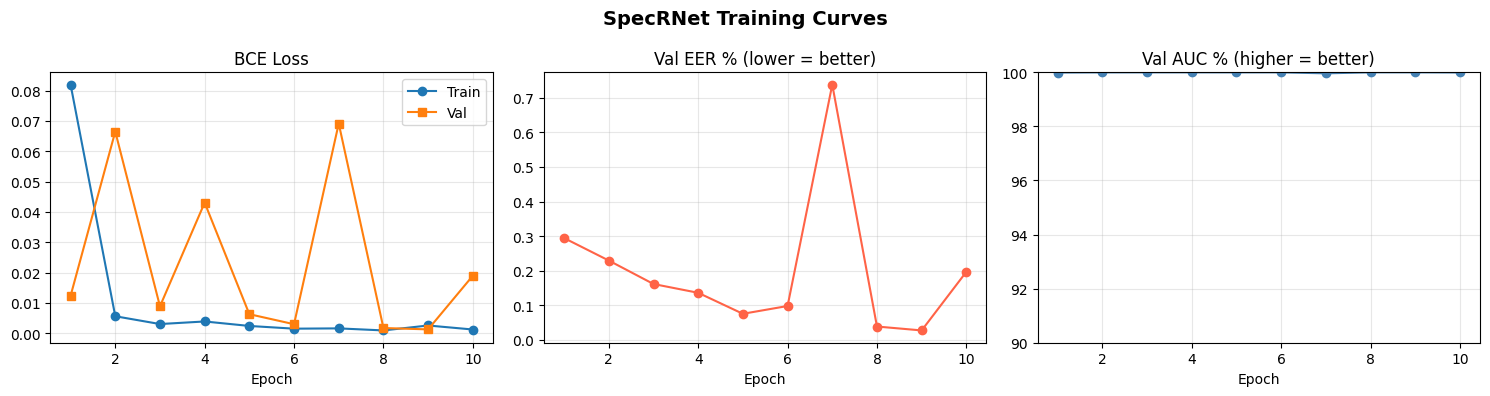

Saved → /content/drive/MyDrive/specrnet_project/results/training_curves.png


In [22]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('SpecRNet Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   marker='s')
axes[0].set_title('BCE Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['val_eer'], color='tomato', marker='o')
axes[1].set_title('Val EER % (lower = better)'); axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_auc'], color='steelblue', marker='o')
axes[2].set_title('Val AUC % (higher = better)'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim([90, 100]); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(RESULTS_DIR, 'training_curves.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {curve_path}')

## Cell 16 — ROC curve

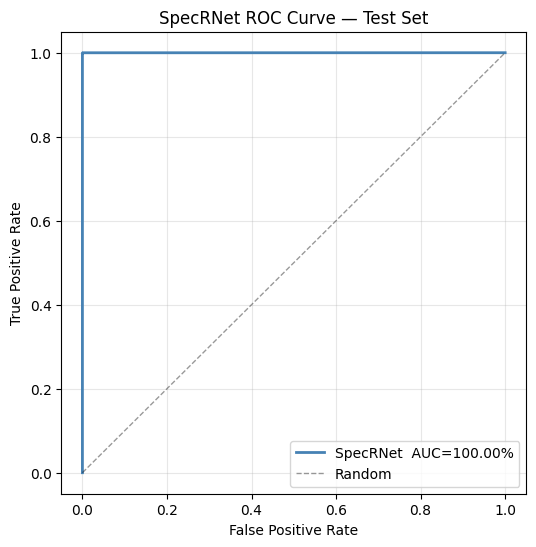

Saved → /content/drive/MyDrive/specrnet_project/results/roc_curve.png


In [23]:
fpr, tpr, _ = roc_curve(test_labels, test_scores)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'SpecRNet  AUC={test_auc:.2f}%')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('SpecRNet ROC Curve — Test Set')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
roc_path = os.path.join(RESULTS_DIR, 'roc_curve.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {roc_path}')

## Cell 17 — Confusion matrix

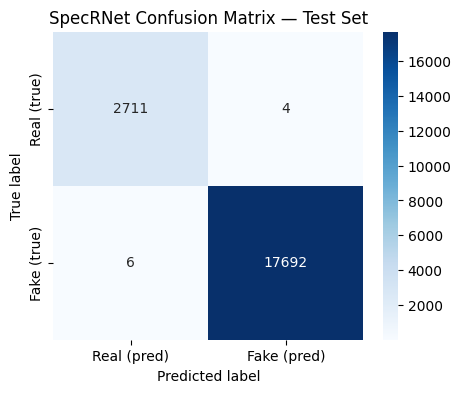

TN=2711  FP=4  FN=6  TP=17692
Precision : 0.9998
Recall    : 0.9997
F1 Score  : 0.9997
Saved → /content/drive/MyDrive/specrnet_project/results/confusion_matrix.png


In [24]:
test_preds = (test_scores >= 0.5).astype(int)
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (pred)', 'Fake (pred)'],
            yticklabels=['Real (true)', 'Fake (true)'], ax=ax)
ax.set_title('SpecRNet Confusion Matrix — Test Set')
ax.set_ylabel('True label'); ax.set_xlabel('Predicted label')
cm_path = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Precision : {tp/(tp+fp):.4f}')
print(f'Recall    : {tp/(tp+fn):.4f}')
print(f'F1 Score  : {2*tp/(2*tp+fp+fn):.4f}')
print(f'Saved → {cm_path}')

## Cell 18 — Save architecture file for fusion notebook

Saves `specrnet_arch.py` to Drive. Your fusion notebook imports from this
file so the class doesn't need to be redefined.

In [25]:
arch_code = '''
import torch
import torch.nn as nn

class FMS(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.fc  = nn.Linear(channels, channels)
        self.sig = nn.Sigmoid()
    def forward(self, x):
        s = x.mean(dim=[2, 3])
        s = self.sig(self.fc(s))
        s = s.unsqueeze(-1).unsqueeze(-1)
        return x * s + s

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, first_block=False):
        super().__init__()
        self.first_block = first_block
        if not first_block:
            self.bn0  = nn.BatchNorm2d(in_ch)
            self.act0 = nn.LeakyReLU(0.3)
        self.bn1   = nn.BatchNorm2d(in_ch)
        self.act1  = nn.LeakyReLU(0.3)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.act2  = nn.LeakyReLU(0.3)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else None
    def forward(self, x):
        identity = x
        if not self.first_block:
            x = self.act0(self.bn0(x))
        out = self.conv1(self.act1(self.bn1(x)))
        out = self.conv2(self.act2(self.bn2(out)))
        if self.shortcut is not None:
            identity = self.shortcut(identity)
        return out + identity

class SpecRNet(nn.Module):
    """
    SpecRNet audio deepfake detector.
    Input : (B, 1, 80, T) LFCC tensor
    Output: (B, 1) probability — 1=fake, 0=real
    """
    def __init__(self):
        super().__init__()
        self.bn_input  = nn.BatchNorm2d(1)
        self.act_input = nn.SELU()
        self.res1   = ResBlock(1,  32, first_block=True)
        self.pool1a = nn.MaxPool2d(2)
        self.fms1   = FMS(32)
        self.pool1b = nn.MaxPool2d(2)
        self.res2   = ResBlock(32, 64)
        self.pool2a = nn.MaxPool2d(2)
        self.fms2   = FMS(64)
        self.pool2b = nn.MaxPool2d(2)
        self.res3   = ResBlock(64, 64)
        self.pool3a = nn.MaxPool2d(2)
        self.fms3   = FMS(64)
        self.pool3b = nn.MaxPool2d(2)
        self.gru1    = nn.GRU(64,  64, batch_first=True, bidirectional=True)
        self.gru2    = nn.GRU(128, 64, batch_first=True, bidirectional=True)
        self.fc1     = nn.Linear(128, 64)
        self.act_fc  = nn.ReLU()
        self.fc2     = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.act_input(self.bn_input(x))
        x = self.pool1b(self.fms1(self.pool1a(self.res1(x))))
        x = self.pool2b(self.fms2(self.pool2a(self.res2(x))))
        x = self.pool3b(self.fms3(self.pool3a(self.res3(x))))
        B, C, H, W = x.shape
        x = x.permute(0, 3, 1, 2).reshape(B, W, C * H)
        x, _ = self.gru1(x)
        x, _ = self.gru2(x)
        x = x[:, -1, :]
        return self.sigmoid(self.fc2(self.act_fc(self.fc1(x))))
'''

arch_path = os.path.join(DRIVE_ROOT, 'specrnet_arch.py')
with open(arch_path, 'w') as f:
    f.write(arch_code)

print('Files saved to Drive for submission and fusion notebook:')
print(f'  Architecture : {arch_path}')
print(f'  Best weights : {best_ckpt_path}')
print(f'  Test metrics : {metrics_path}')
print(f'  History JSON : {hist_path}')
print(f'  Plots        : {RESULTS_DIR}/')
print(f'  LFCC cache   : {CACHE_DIR}/  (~15 GB — share this folder link)')
print()
print('To load SpecRNet in another notebook:')
print('  import sys')
print('  sys.path.append("/content/drive/MyDrive/specrnet_project")')
print('  from specrnet_arch import SpecRNet')
print('  model = SpecRNet()')
print('  ckpt  = torch.load("specrnet_best.pt", map_location=device)')
print('  model.load_state_dict(ckpt["model_state"])')
print('  model.eval()')

Files saved to Drive for submission and fusion notebook:
  Architecture : /content/drive/MyDrive/specrnet_project/specrnet_arch.py
  Best weights : /content/drive/MyDrive/specrnet_project/checkpoints/specrnet_best.pt
  Test metrics : /content/drive/MyDrive/specrnet_project/results/test_metrics.json
  History JSON : /content/drive/MyDrive/specrnet_project/results/training_history.json
  Plots        : /content/drive/MyDrive/specrnet_project/results/
  LFCC cache   : /content/drive/MyDrive/specrnet_project/lfcc_cache/  (~15 GB — share this folder link)

To load SpecRNet in another notebook:
  import sys
  sys.path.append("/content/drive/MyDrive/specrnet_project")
  from specrnet_arch import SpecRNet
  model = SpecRNet()
  ckpt  = torch.load("specrnet_best.pt", map_location=device)
  model.load_state_dict(ckpt["model_state"])
  model.eval()
